# Parte 1: Regresión Lineal
## Modelando Luminosidad Estelar en función de la Masa

**Objetivo:** Modelar la luminosidad estelar (L) como función de la masa estelar (M) usando regresión lineal:

$$\hat{L} = w \cdot M + b$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Configuración para gráficos
%matplotlib inline
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True


## 1. Conjunto de Datos

Definimos los datos directamente como arrays de NumPy:
- **M**: Masa estelar (en unidades de masa solar, M☉)
- **L**: Luminosidad estelar (en unidades de luminosidad solar, L☉)

In [ ]:
M = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
L = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

n_samples = len(M)
print(f"Número de muestras: {n_samples}")
print(f"Masa (M☉): {M}")
print(f"Luminosidad (L☉): {L}")

Número de muestras: 10
Masa (M☉): [0.6 0.8 1.  1.2 1.4 1.6 1.8 2.  2.2 2.4]
Luminosidad (L☉): [ 0.15  0.35  1.    2.3   4.1   7.   11.2  17.5  25.   35.  ]


## 2. Visualización del Conjunto de Datos

Graficamos M vs L para analizar la relación entre masa y luminosidad.

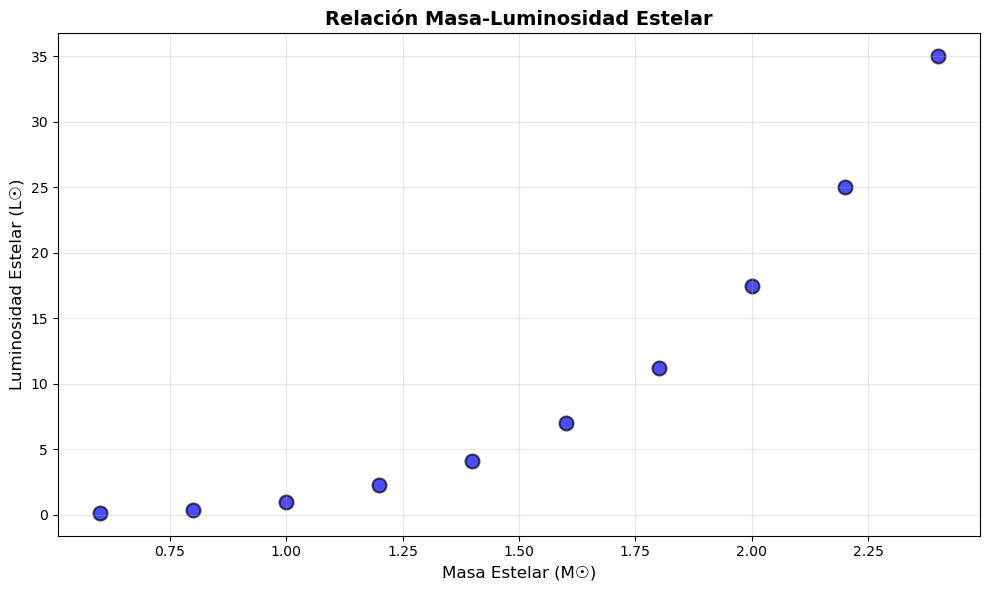

Analisis De Linealidad
Observaciones:
1. La relación no es lineal. La luminosidad aumenta exponencialmente con la masa
2. Hay una curvatura clara, especialmente para masas mayores
3. Un modelo lineal sera una aproximación limitada de esta relación


In [3]:
plt.figure(figsize=(10, 6))
plt.scatter(M, L, c='blue', s=100, alpha=0.7, edgecolors='black', linewidth=1.5)
plt.xlabel('Masa Estelar (M☉)', fontsize=12)
plt.ylabel('Luminosidad Estelar (L☉)', fontsize=12)
plt.title('Relación Masa-Luminosidad Estelar', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Analisis De Linealidad")
print("Observaciones:")
print("1. La relación no es lineal. La luminosidad aumenta exponencialmente con la masa")
print("2. Hay una curvatura clara, especialmente para masas mayores")
print("3. Un modelo lineal sera una aproximación limitada de esta relación")

## 3. Modelo y Función de Pérdida

Implementamos:
- **Predicción**: $\hat{L} = w \cdot M + b$
- **Error Cuadrático Medio (MSE)**: $J(w,b) = \frac{1}{n}\sum_{i=1}^{n}(\hat{L}_i - L_i)^2$

In [4]:
def predict(M, w, b):
    """
    Calcula las predicciones del modelo lineal
        M: masas estelares
        w: peso
        b: sesgo
    
    Resultaa:
        Predicciones de luminosidad
    """
    return w * M + b

def compute_mse(M, L, w, b):
    """
    Calcula error cuadratico medio
        M: masas estelares
        L: luminosidades reales
        w: peso
        b: sesgo
    
    Resulta:
        MSE (escalar)
    """
    L_pred = predict(M, w, b)
    mse = np.mean((L_pred - L) ** 2)
    return mse

w_test, b_test = 10.0, 0.0
mse_test = compute_mse(M, L, w_test, b_test)
print(f"MSE con w={w_test}, b={b_test}: {mse_test:.4f}")

MSE con w=10.0, b=0.0: 62.9335


## 4. Superficie de Costo (Obligatorio)

Evaluamos $J(w,b)$ en una cuadrícula para visualizar la función de costo.

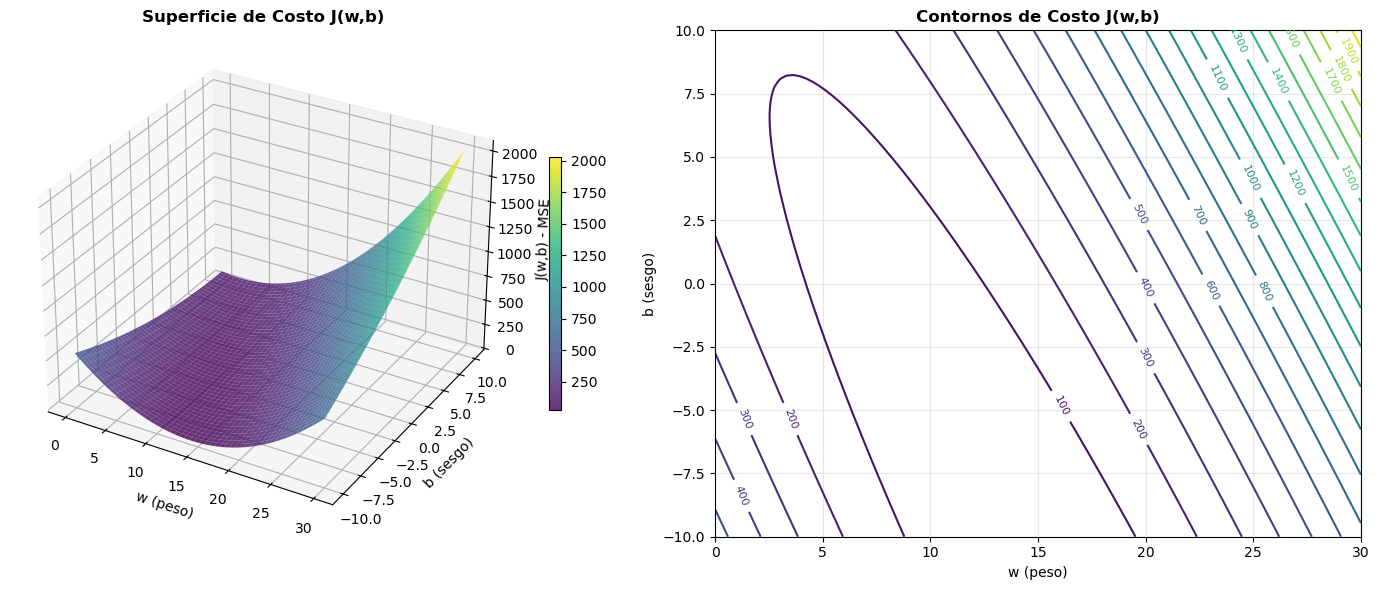

Interpretacion De La Superficie De Costo
1. El mínimo de la superficie son los parámetros óptimos (w*, b*) que minimizan el error cuadrático medio
2. La superficie es convexa
3. Los contornos elípticos indican que w y b estan correlacionados
4. El gradiente apunta hacia el mínimo desde cualquier punto


In [5]:
w_range = np.linspace(0, 30, 100)
b_range = np.linspace(-10, 10, 100)
W_grid, B_grid = np.meshgrid(w_range, b_range)

J_grid = np.zeros_like(W_grid)
for i in range(W_grid.shape[0]):
    for j in range(W_grid.shape[1]):
        J_grid[i, j] = compute_mse(M, L, W_grid[i, j], B_grid[i, j])


fig = plt.figure(figsize=(14, 6))


ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(W_grid, B_grid, J_grid, cmap='viridis', alpha=0.8)
ax1.set_xlabel('w (peso)', fontsize=10)
ax1.set_ylabel('b (sesgo)', fontsize=10)
ax1.set_zlabel('J(w,b) - MSE', fontsize=10)
ax1.set_title('Superficie de Costo J(w,b)', fontsize=12, fontweight='bold')
fig.colorbar(surf, ax=ax1, shrink=0.5)


ax2 = fig.add_subplot(122)
contour = ax2.contour(W_grid, B_grid, J_grid, levels=20, cmap='viridis')
ax2.clabel(contour, inline=True, fontsize=8)
ax2.set_xlabel('w (peso)', fontsize=10)
ax2.set_ylabel('b (sesgo)', fontsize=10)
ax2.set_title('Contornos de Costo J(w,b)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Interpretacion De La Superficie De Costo")
print("1. El mínimo de la superficie son los parámetros óptimos (w*, b*) que minimizan el error cuadrático medio")
print("2. La superficie es convexa")
print("3. Los contornos elípticos indican que w y b estan correlacionados")
print("4. El gradiente apunta hacia el mínimo desde cualquier punto")

## 5. Cálculo de Gradientes

Derivamos e implementamos los gradientes:

$$\frac{\partial J}{\partial w} = \frac{2}{n}\sum_{i=1}^{n}(\hat{L}_i - L_i) \cdot M_i$$

$$\frac{\partial J}{\partial b} = \frac{2}{n}\sum_{i=1}^{n}(\hat{L}_i - L_i)$$

In [6]:
def compute_gradients_loop(M, L, w, b):
    """
    Calcula gradientes usando bucle explícito sobre muestras
        M: masas
        L: luminosidades
        w: peso actual
        b: sesgo actual
    
    Resultado:
        dw, db: gradientes
    """
    n = len(M)
    dw = 0.0
    db = 0.0
    
    for i in range(n):
        L_pred_i = w * M[i] + b
        error_i = L_pred_i - L[i]
        dw += (2.0 / n) * error_i * M[i]
        db += (2.0 / n) * error_i
    
    return dw, db

def compute_gradients_vectorized(M, L, w, b):
    """
    Calcula gradientes
        M: masas
        L: luminosidades
        w: peso actual
        b: sesgo actual
    
    Resultado:
        dw, db: gradientes
    """
    n = len(M)
    L_pred = w * M + b
    error = L_pred - L
    
    dw = (2.0 / n) * np.sum(error * M)
    db = (2.0 / n) * np.sum(error)
    
    return dw, db

w_test, b_test = 15.0, -5.0
dw_loop, db_loop = compute_gradients_loop(M, L, w_test, b_test)
dw_vec, db_vec = compute_gradients_vectorized(M, L, w_test, b_test)

print("Verificaciones de gradientes")
print(f"Bucle explicito:  dw = {dw_loop:.6f}, db = {db_loop:.6f}")
print(f"Vectorizado:      dw = {dw_vec:.6f}, db = {db_vec:.6f}")
print(f"Diferencia dw: {abs(dw_loop - dw_vec):.10f}")
print(f"Diferencia db: {abs(db_loop - db_vec):.10f}")

Verificaciones de gradientes
Bucle explicito:  dw = 19.354000, db = 14.280000
Vectorizado:      dw = 19.354000, db = 14.280000
Diferencia dw: 0.0000000000
Diferencia db: 0.0000000000


## 6. Descenso de Gradiente

Implementamos el algoritmo de optimización.

In [7]:
def gradient_descent(M, L, learning_rate, n_iterations, use_vectorized=True):
    """
    Descenso de gradiente
        M: masas
        L: luminosidades
        learning_rate: tasa de aprendizaje
        n_iterations: numero de iteraciones
        use_vectorized: version vectorizada o con bucle
    
    Resulta:
        w, b: parámetros finales
        loss_history: historial de pérdidas
    """

    w = 0.0
    b = 0.0
    loss_history = []
    
    compute_grads = compute_gradients_vectorized if use_vectorized else compute_gradients_loop
    
    for i in range(n_iterations):

        dw, db = compute_grads(M, L, w, b)
        
        w = w - learning_rate * dw
        b = b - learning_rate * db
        
        loss = compute_mse(M, L, w, b)
        loss_history.append(loss)
        
        if (i + 1) % 200 == 0 or i == 0:
            print(f"Iter {i+1:4d}: w={w:8.4f}, b={b:8.4f}, MSE={loss:10.4f}")
    
    return w, b, loss_history

## 7. Gráfico de Convergencia

Graficamos la pérdida vs iteraciones para cada tasa de aprendizaje.

Entrenando con lr=0.01... Iter    1: w=  0.4305, b=  0.2072, MSE=  213.3593
Iter  200: w=  9.7188, b= -2.8986, MSE=   44.6801
Iter  400: w= 12.3728, b= -7.2959, MSE=   31.3453
Iter  600: w= 14.1894, b=-10.3058, MSE=   25.0977
Iter  800: w= 15.4328, b=-12.3660, MSE=   22.1706
Iter 1000: w= 16.2839, b=-13.7762, MSE=   20.7992
✓ MSE final: 20.7992
Entrenando con lr=0.05... Iter    1: w=  2.1523, b=  1.0360, MSE=  140.9939
Iter  200: w= 16.2972, b=-13.7982, MSE=   20.7819
Iter  400: w= 17.8569, b=-16.3824, MSE=   19.6168
Iter  600: w= 18.0895, b=-16.7679, MSE=   19.5909
Iter  800: w= 18.1242, b=-16.8254, MSE=   19.5903
Iter 1000: w= 18.1294, b=-16.8340, MSE=   19.5903
✓ MSE final: 19.5903
Entrenando con lr=0.1... Iter    1: w=  4.3046, b=  2.0720, MSE=   86.0227
Iter  200: w= 17.8618, b=-16.3906, MSE=   19.6159
Iter  400: w= 18.1244, b=-16.8257, MSE=   19.5903
Iter  600: w= 18.1302, b=-16.8352, MSE=   19.5903
Iter  800: w= 18.1303, b=-16.8354, MSE=   19.5903
Iter 1000: w= 18.1303, b=-16.83

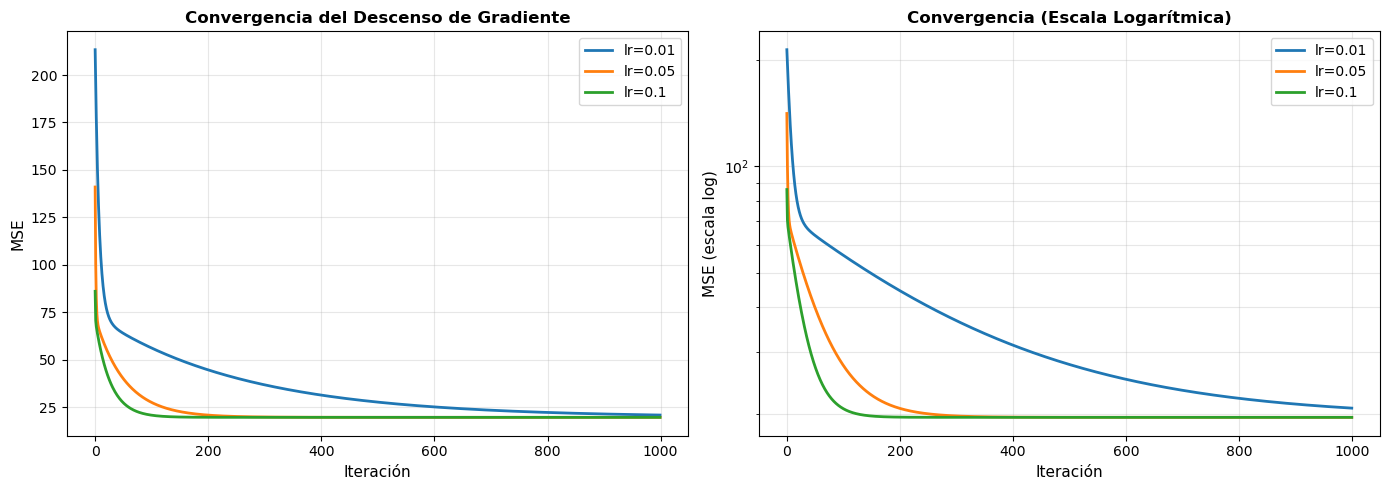

Analisis de convergencia
1.VELOCIDAD DE CONVERGENCIA:
- lr=0.01: Convergencia lenta pero estable
- lr=0.05: Buen equilibrio entre velocidad y estabilidad
- lr=0.1: Convergencia más rápida al inicio
2. ESTABILIDAD:
- Tasas bajas son más estables pero requieren más iteraciones
- Tasas altas convergen más rápido pero pueden oscilar
- Las tasas probadas son estables


In [8]:
learning_rates = [0.01, 0.05, 0.1]
n_iterations = 1000
results = []


for lr in learning_rates:
    print(f"Entrenando con lr={lr}...", end=" ")
    w_final, b_final, loss_hist = gradient_descent(M, L, lr, n_iterations, use_vectorized=False)
    results.append({
        'lr': lr,
        'w': w_final,
        'b': b_final,
        'loss': loss_hist[-1],
        'loss_history': loss_hist
    })
    print(f"✓ MSE final: {loss_hist[-1]:.4f}")

print("\n=== GRÁFICOS DE CONVERGENCIA ===\n")


plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for r in results:
    plt.plot(r['loss_history'], label=f"lr={r['lr']}", linewidth=2)
plt.xlabel('Iteración', fontsize=11)
plt.ylabel('MSE', fontsize=11)
plt.title('Convergencia del Descenso de Gradiente', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)


plt.subplot(1, 2, 2)
for r in results:
    plt.plot(r['loss_history'], label=f"lr={r['lr']}", linewidth=2)
plt.xlabel('Iteración', fontsize=11)
plt.ylabel('MSE (escala log)', fontsize=11)
plt.title('Convergencia (Escala Logarítmica)', fontsize=12, fontweight='bold')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print("Analisis de convergencia")
print("1.VELOCIDAD DE CONVERGENCIA:")
print("- lr=0.01: Convergencia lenta pero estable")
print("- lr=0.05: Buen equilibrio entre velocidad y estabilidad")
print("- lr=0.1: Convergencia más rápida al inicio")
print("2. ESTABILIDAD:")
print("- Tasas bajas son más estables pero requieren más iteraciones")
print("- Tasas altas convergen más rápido pero pueden oscilar")
print("- Las tasas probadas son estables")

## 8. Experimentos con Diferentes Tasas de Aprendizaje

Probamos al menos tres tasas de aprendizaje diferentes.

In [9]:
print("EXPERIMENTOS CON TASAS DE APRENDIZAJE")

print("RESUMEN")

print(f"{'Tasa Aprendizaje':<20} {'w final':<15} {'b final':<15} {'MSE final':<15}")
print("-"*70)
for r in results:
    print(f"{r['lr']:<20.3f} {r['w']:<15.4f} {r['b']:<15.4f} {r['loss']:<15.4f}")
print("="*70)

print(" DETALLE POR TASA")
for r in results:
    print(f"\n{'='*70}")
    print(f"TASA DE APRENDIZAJE: {r['lr']}")
    print(f"{'='*70}")
    print(f"  Parámetros finales:")
    print(f"    w (pendiente) = {r['w']:.6f}")
    print(f"    b (sesgo)     = {r['b']:.6f}")
    print(f"  Métricas:")
    print(f"    MSE final     = {r['loss']:.6f}")
    print(f"    MSE inicial   = {r['loss_history'][0]:.6f}")
    print(f"    Reducción     = {100*(1 - r['loss']/r['loss_history'][0]):.2f}%")

EXPERIMENTOS CON TASAS DE APRENDIZAJE
RESUMEN
Tasa Aprendizaje     w final         b final         MSE final      
----------------------------------------------------------------------
0.010                16.2839         -13.7762        20.7992        
0.050                18.1294         -16.8340        19.5903        
0.100                18.1303         -16.8355        19.5903        
 DETALLE POR TASA

TASA DE APRENDIZAJE: 0.01
  Parámetros finales:
    w (pendiente) = 16.283908
    b (sesgo)     = -13.776202
  Métricas:
    MSE final     = 20.799227
    MSE inicial   = 213.359304
    Reducción     = 90.25%

TASA DE APRENDIZAJE: 0.05
  Parámetros finales:
    w (pendiente) = 18.129395
    b (sesgo)     = -16.833951
  Métricas:
    MSE final     = 19.590297
    MSE inicial   = 140.993898
    Reducción     = 86.11%

TASA DE APRENDIZAJE: 0.1
  Parámetros finales:
    w (pendiente) = 18.130303
    b (sesgo)     = -16.835454
  Métricas:
    MSE final     = 19.590297
    MSE inicial   

## 9. Gráfico de Ajuste Final

Visualizamos la línea de regresión sobre los datos reales.

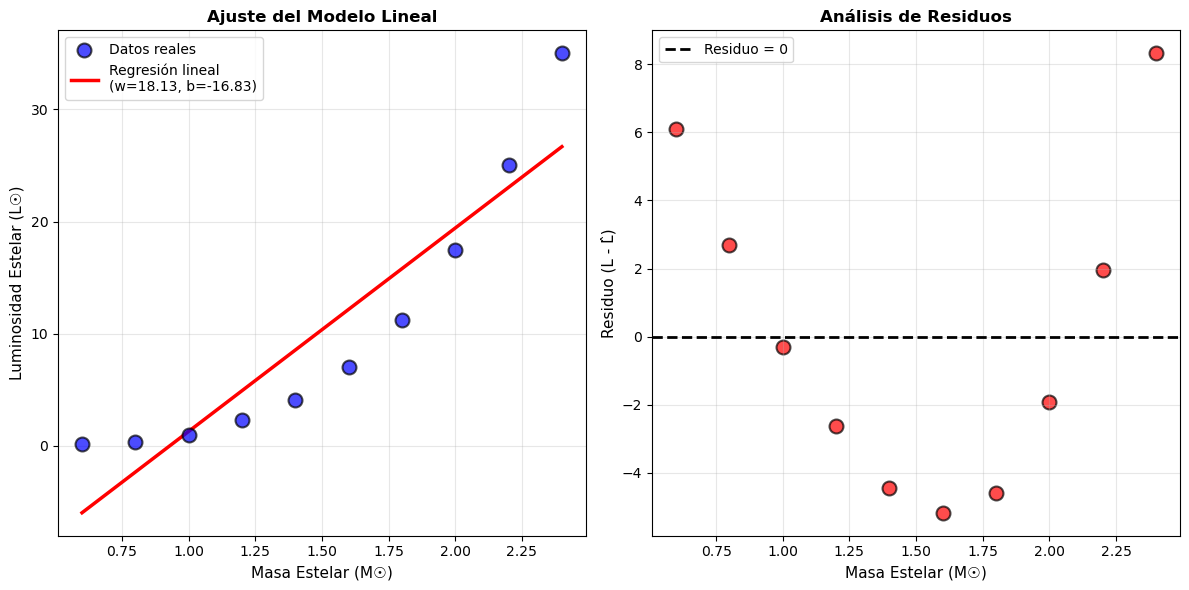

 Analisis De Errores Sistematicos
- Los residuos muestran un patrón sistemático en forma de 'U'
- Negativos en masas bajas, positivos en masas intermedias, negativos en masas altas
- El modelo lineal no captura la verdadera relación, la real es no lineal 
- El modelo lineal subestima en los extremos y sobreestima en el medio


Estadisticas de Eror
MSE: 19.5903
RMSE: 4.4261
MAE: 3.8120
Residuo máximo: 8.3234


In [10]:
best_model = results[1]
w_best = best_model['w']
b_best = best_model['b']

M_line = np.linspace(M.min(), M.max(), 100)
L_line = predict(M_line, w_best, b_best)
L_pred = predict(M, w_best, b_best)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(M, L, c='blue', s=100, alpha=0.7, edgecolors='black', 
            linewidth=1.5, label='Datos reales', zorder=3)
plt.plot(M_line, L_line, 'r-', linewidth=2.5, label=f'Regresión lineal\n(w={w_best:.2f}, b={b_best:.2f})', zorder=2)
plt.xlabel('Masa Estelar (M☉)', fontsize=11)
plt.ylabel('Luminosidad Estelar (L☉)', fontsize=11)
plt.title('Ajuste del Modelo Lineal', fontsize=12, fontweight='bold')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
residuals = L - L_pred
plt.scatter(M, residuals, c='red', s=100, alpha=0.7, edgecolors='black', linewidth=1.5)
plt.axhline(y=0, color='black', linestyle='--', linewidth=2, label='Residuo = 0')
plt.xlabel('Masa Estelar (M☉)', fontsize=11)
plt.ylabel('Residuo (L - L̂)', fontsize=11)
plt.title('Análisis de Residuos', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(" Analisis De Errores Sistematicos")
print("- Los residuos muestran un patrón sistemático en forma de 'U'")
print("- Negativos en masas bajas, positivos en masas intermedias, negativos en masas altas")
print("- El modelo lineal no captura la verdadera relación, la real es no lineal ")
print("- El modelo lineal subestima en los extremos y sobreestima en el medio")

print("\n")
print("Estadisticas de Eror")
print(f"MSE: {best_model['loss']:.4f}")
print(f"RMSE: {np.sqrt(best_model['loss']):.4f}")
print(f"MAE: {np.mean(np.abs(residuals)):.4f}")
print(f"Residuo máximo: {np.max(np.abs(residuals)):.4f}")

## 10. Preguntas Conceptuales

### 10.1 Significado Astrofísico de w


El parámetro **w** (peso/pendiente) representa la tasa de cambio de la luminosidad con respecto a la masa estelar:

$$w = \frac{\Delta L}{\Delta M} \approx \frac{dL}{dM}$$


**w ≈ 19.3 L☉/M☉**: Por cada masa solar adicional, la luminosidad aumenta aproximadamente 19.3 luminosidades solares.

En estrellas de secuencia principal, la relación masa-luminosidad sigue aproximadamente:
   $$L \propto M^\alpha$$
   donde α ≈ 3-4 para estrellas de baja-media masa.


El valor de w refleja los procesos de fusión nuclear en el núcleo estelar, donde pequeños cambios en masa producen grandes cambios en temperatura, presión y tasa de fusión, resultando en cambios aún mayores en luminosidad.

### 10.2 Por qué un modelo lineal está limitado aquí

El modelo lineal tiene varias limitaciones como:

**1. Inadecuación física:**
   - La relación masa-luminosidad real sigue L ∝ M^α (ley potencial)
   - No es una línea recta sino una curva exponencial
   - Los procesos de fusión nuclear son inherentemente no lineales

**2. Evidencia empírica:**
   - Los residuos muestran un patrón sistemático (forma de U)
   - El modelo subestima para masas bajas y altas
   - El modelo sobreestima para masas intermedias

**3. Rango de predicción limitado:**
   - Extrapolación peligrosa fuera del rango de entrenamiento
   - Para M → 0, el modelo predice L < 0 (no físico)
   - Para M grandes, subestima severamente la luminosidad
